In [1]:
import torch
import numpy as np
import pandas as pd
from itertools import chain
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score

import nltk
from nltk.corpus import stopwords as nltk_stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# cuML GPU imports for WSL
from cuml.manifold import UMAP
from cuml.cluster import KMeans

# Verify GPU device availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
if device.type == "cuda":
  print("GPU    :", torch.cuda.get_device_name(0))

Device : cuda
GPU    : NVIDIA GeForce GTX 1650 Ti


# stopwords & bertopic components

In [2]:
nltk.download('stopwords', quiet=True)

sastrawi_stopwords = StopWordRemoverFactory().get_stop_words()
pure_stopwords = list(set(nltk_stopwords.words('indonesian')).union(set(sastrawi_stopwords)))

# Topic stopwords excluding common bank names across dataset
topic_stopwords = list(set(
    pure_stopwords + [
        "brimo", "livin", "mandiri", "bca", "bni", "wondr"
    ]
))

ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True,
    bm25_weighting=True
)

# evaluation metrics calculation function

In [3]:
def calculate_silhouette(umap_embeddings, topics):
  """Calculates Cosine Silhouette Score on UMAP embeddings excluding outliers."""
  topics_arr = np.array(topics)
  mask = topics_arr != -1
  
  unique_clusters = set(topics_arr[mask])
  if len(unique_clusters) < 2:
      return 0.0
      
  score = silhouette_score(
      umap_embeddings[mask],
      topics_arr[mask],
      metric="cosine"
  )
  return float(score)

def calculate_topic_diversity(topic_model, top_n=10):
  """Calculates Topic Diversity across all non-outlier clusters."""
  topic_info = topic_model.get_topic_info()
  valid_topics = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()
  
  topic_words = []
  for topic in valid_topics:
      words = [word for word, _ in topic_model.get_topic(topic)[:top_n]]
      topic_words.append(words)
      
  flat_words = list(chain.from_iterable(topic_words))
  if not flat_words:
      return 0.0
      
  return len(set(flat_words)) / len(flat_words)

def calculate_npmi(topic_model, documents, top_n=10):
  """Calculates NPMI Coherence using Gensim CoherenceModel."""
  analyzer = topic_model.vectorizer_model.build_analyzer()
  tokenized_docs = [analyzer(doc) for doc in documents]
  dictionary = Dictionary(tokenized_docs)
  
  topic_info = topic_model.get_topic_info()
  valid_topics = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()
  
  topic_words = []
  for topic in valid_topics:
      words = [
          word for word, _ in topic_model.get_topic(topic)[:top_n]
          if word in dictionary.token2id
      ]
      if len(words) >= 2:
          topic_words.append(words)
          
  if not topic_words:
      return 0.0
      
  coherence_model = CoherenceModel(
      topics=topic_words,
      texts=tokenized_docs,
      dictionary=dictionary,
      coherence="c_npmi"
  )
  return float(coherence_model.get_coherence())

# Data & Embedding Initialization per Bank

In [4]:
df = pd.read_csv("preprocessed_data_2025.csv")

# Bank key mapping definition
bank_mapping = [
  {"key": "LIVIN_MANDIRI_REVIEWS", "display": "Mandiri"},
  {"key": "BRIMO_REVIEWS", "display": "BRI"},
  {"key": "WONDR_BNI_REVIEWS", "display": "BNI"},
  {"key": "BCAMOBILE_REVIEWS", "display": "BCA"}
]

# Load SimCSE-IndoBERT SentenceTransformer onto GPU
embedding_model = SentenceTransformer("LazarusNLP/simcse-indobert-base", device=device)

# Pre-compute embeddings per bank to avoid redundant GPU passes
bank_data_store = {}

for bank_info in bank_mapping:
  bank_key = bank_info["key"]
  display_name = bank_info["display"]
  
  sub_df = df[df["bank"] == bank_key].reset_index(drop=True)
  docs = sub_df["text"].astype(str).tolist()
  
  print(f"Generating GPU Embeddings for {display_name} ({len(docs):,} rows)...")
  embeddings = embedding_model.encode(
      docs,
      batch_size=128,
      show_progress_bar=False,
      convert_to_numpy=True,
      normalize_embeddings=True
  )
  
  bank_data_store[display_name] = {
      "docs": docs,
      "embeddings": embeddings,
      "total_data": len(docs)
  }

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Generating GPU Embeddings for Mandiri (14,408 rows)...
Generating GPU Embeddings for BRI (18,412 rows)...
Generating GPU Embeddings for BNI (11,307 rows)...
Generating GPU Embeddings for BCA (7,687 rows)...


# Systematic Evaluation Loop

In [50]:
k_values = [4, 6, 8, 10, 12]
all_results = {}

for k in k_values:
  print(f" RUNNING EVALUATION FOR K = {k}")
  
  k_table_rows = []
  
  for bank_info in bank_mapping:
      bank_name = bank_info["display"]
      docs = bank_data_store[bank_name]["docs"]
      embeddings = bank_data_store[bank_name]["embeddings"]
      total_data = bank_data_store[bank_name]["total_data"]
      
      # GPU UMAP Dimensionality Reduction
      umap_gpu = UMAP(
          n_neighbors=15,
          n_components=10,
          metric="cosine",
          min_dist=0.0,
          random_state=42
      )

      bank_vectorizer = CountVectorizer(
        ngram_range=(1, 2),
        stop_words=topic_stopwords,
        token_pattern=r"(?u)\b[^\d\W]{2,}\b",
        min_df=0.01
    )
      
      # GPU K-Means Clustering
      kmeans_gpu = KMeans(
          n_clusters=k,
          init="k-means++",
          max_iter=300,
          random_state=42
      )
      
      # Construct BERTopic Pipeline
      topic_model = BERTopic(
          embedding_model=None,
          calculate_probabilities=False,
          vectorizer_model=bank_vectorizer,
          umap_model=umap_gpu,
          hdbscan_model=kmeans_gpu,
          ctfidf_model=ctfidf_model,
          verbose=False
      )
      
      # Fit topic model
      topics, _ = topic_model.fit_transform(docs, embeddings)
      
      # Calculate Evaluation Metrics
      sil_score = calculate_silhouette(topic_model.umap_model.embedding_, topics)
      npmi_score = calculate_npmi(topic_model, docs, top_n=10)
      td_score = calculate_topic_diversity(topic_model, top_n=10)
      
      k_table_rows.append({
          "Bank": bank_name,
          "Silhouette": sil_score,
          "NPMI": npmi_score,
          "Topic Diversity": td_score,
          "Total Data": total_data
      })
      
      print(f"  Finished {bank_name:<8} -> Silhouette: {sil_score:.4f} | NPMI: {npmi_score:.4f} | Diversity: {td_score:.2f}")
      
  all_results[k] = pd.DataFrame(k_table_rows)

 RUNNING EVALUATION FOR K = 4
  Finished Mandiri  -> Silhouette: 0.4730 | NPMI: 0.0872 | Diversity: 0.72
  Finished BRI      -> Silhouette: 0.5736 | NPMI: 0.1271 | Diversity: 0.80
  Finished BNI      -> Silhouette: 0.5284 | NPMI: 0.1047 | Diversity: 0.82
  Finished BCA      -> Silhouette: 0.5315 | NPMI: 0.1735 | Diversity: 0.93
 RUNNING EVALUATION FOR K = 6
  Finished Mandiri  -> Silhouette: 0.4997 | NPMI: 0.1237 | Diversity: 0.85
  Finished BRI      -> Silhouette: 0.5235 | NPMI: 0.1568 | Diversity: 0.83
  Finished BNI      -> Silhouette: 0.4414 | NPMI: 0.1064 | Diversity: 0.78
  Finished BCA      -> Silhouette: 0.5257 | NPMI: 0.2348 | Diversity: 0.97
 RUNNING EVALUATION FOR K = 8
  Finished Mandiri  -> Silhouette: 0.3834 | NPMI: 0.1653 | Diversity: 0.88
  Finished BRI      -> Silhouette: 0.3712 | NPMI: 0.1567 | Diversity: 0.79
  Finished BNI      -> Silhouette: 0.4762 | NPMI: 0.1312 | Diversity: 0.79
  Finished BCA      -> Silhouette: 0.5497 | NPMI: 0.2001 | Diversity: 0.91
 RUNNING E

# Table Rendering

In [51]:
def style_evaluation_table(df, k_val):
    """Formats DataFrame output matching specified evaluation template."""
    formatted_df = df.copy()
    
    # Format floating point numbers to matched decimal places and commas
    formatted_df["Silhouette"] = formatted_df["Silhouette"].apply(lambda x: f"{x:.4f}".replace(".", ","))
    formatted_df["NPMI"] = formatted_df["NPMI"].apply(lambda x: f"{x:.4f}".replace(".", ","))
    formatted_df["Topic Diversity"] = formatted_df["Topic Diversity"].apply(lambda x: f"{x:.2f}".replace(".", ","))
    formatted_df["Total Data"] = formatted_df["Total Data"].apply(lambda x: f"{x:,}".replace(",", "."))
    
    caption_title = f"Evaluation using K-MEANS with simcse - IndoBERT (K = {k_val})"
    
    # Apply Pandas HTML Styling
    styled = (
        formatted_df.style
        .set_caption(f"<div style='background-color:#FFC000; color:black; font-weight:bold; padding:6px; font-size:14px; text-align:center;'>{caption_title}</div>")
        .set_properties(**{'text-align': 'left'}, subset=['Bank'])
        .set_properties(**{'text-align': 'right'}, subset=['Silhouette', 'NPMI', 'Topic Diversity', 'Total Data'])
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#D9E1F2'), ('color', 'black'), ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]},
            {'selector': 'td', 'props': [('border', '1px solid black')]},
            {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]}
        ])
        .hide(axis='index')
    )
    return styled

# Display all evaluation tables for K = 4, 6, 8, 10, 12
for k_val, res_df in all_results.items():
    display(style_evaluation_table(res_df, k_val))

Bank,Silhouette,NPMI,Topic Diversity,Total Data
Mandiri,"0,4730","0,0872","0,72",14.408
BRI,"0,5736","0,1271","0,80",18.412
BNI,"0,5284","0,1047","0,82",11.307
BCA,"0,5315","0,1735","0,93",7.687


Bank,Silhouette,NPMI,Topic Diversity,Total Data
Mandiri,"0,4997","0,1237","0,85",14.408
BRI,"0,5235","0,1568","0,83",18.412
BNI,"0,4414","0,1064","0,78",11.307
BCA,"0,5257","0,2348","0,97",7.687


Bank,Silhouette,NPMI,Topic Diversity,Total Data
Mandiri,"0,3834","0,1653","0,88",14.408
BRI,"0,3712","0,1567","0,79",18.412
BNI,"0,4762","0,1312","0,79",11.307
BCA,"0,5497","0,2001","0,91",7.687


Bank,Silhouette,NPMI,Topic Diversity,Total Data
Mandiri,"0,3488","0,1538","0,86",14.408
BRI,"0,3077","0,1566","0,81",18.412
BNI,"0,4138","0,1668","0,81",11.307
BCA,"0,5619","0,1771","0,90",7.687


Bank,Silhouette,NPMI,Topic Diversity,Total Data
Mandiri,"0,3442","0,1404","0,78",14.408
BRI,"0,3337","0,1433","0,82",18.412
BNI,"0,4079","0,1487","0,78",11.307
BCA,"0,5213","0,1760","0,88",7.687


# Generate Top-10 Topic Words & Representative Reviews to DOCX

In [47]:
import os
import docx
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

In [48]:
def set_cell_background(cell, fill_hex):
    """Utility to set table cell background color."""
    tcPr = cell._element.get_or_add_tcPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:val'), 'clear')
    shd.set(qn('w:color'), 'auto')
    shd.set(qn('w:fill'), fill_hex)
    tcPr.append(shd)

def export_topics_to_docx_per_k_with_eval(
    bank_data_store, 
    bank_mapping, 
    topic_stopwords, 
    ctfidf_model, 
    all_results,  # Passes the evaluation DataFrames from the previous cell
    k_values=[4, 6, 8, 10, 12]
):
    """Generates a separate DOCX file for each K value containing the evaluation summary table, 
    topic words, and representative reviews."""
    
    for k in k_values:
        output_filename = f"Bank_Topic_Modeling_Evaluation_K{k}.docx"
        doc = Document()
        
        # Document Page Margins
        sections = doc.sections
        for section in sections:
            section.top_margin = Inches(0.8)
            section.bottom_margin = Inches(0.8)
            section.left_margin = Inches(0.8)
            section.right_margin = Inches(0.8)

        # Title
        title_p = doc.add_paragraph()
        title_p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        title_run = title_p.add_run(f"KBMI 4 Mobile Banking Review Analysis\nTopic Modeling Evaluation (K = {k})")
        title_run.font.name = "Calibri"
        title_run.font.size = Pt(18)
        title_run.font.bold = True
        title_run.font.color.rgb = RGBColor(31, 78, 121)

        print(f"\n========================================================")
        print(f" GENERATING DOCX FOR K = {k} -> {output_filename}")
        print(f"========================================================")

        # ----------------------------------------------------------------------
        # 1. OVERALL EVALUATION TABLE FOR K
        # ----------------------------------------------------------------------
        if k in all_results:
            eval_df = all_results[k]
            
            summary_title = doc.add_paragraph()
            summary_title.paragraph_format.space_before = Pt(12)
            summary_title.paragraph_format.space_after = Pt(4)
            st_run = summary_title.add_run(f"Evaluation Summary using K-MEANS with simcse - IndoBERT (K = {k})")
            st_run.font.name = "Calibri"
            st_run.font.size = Pt(12)
            st_run.font.bold = True
            st_run.font.color.rgb = RGBColor(192, 0, 0)

            # Build Evaluation Table
            eval_table = doc.add_table(rows=len(eval_df) + 1, cols=5)
            eval_table.style = 'Table Grid'
            eval_table.autofit = False

            # Header Row
            headers = ["Bank", "Silhouette", "NPMI", "Topic Diversity", "Total Data"]
            hdr_cells = eval_table.rows[0].cells
            for col_idx, text in enumerate(headers):
                hdr_cells[col_idx].text = text
                set_cell_background(hdr_cells[col_idx], "FFC000")  # Matching yellow banner background
                hdr_p = hdr_cells[col_idx].paragraphs[0]
                hdr_p.alignment = WD_ALIGN_PARAGRAPH.CENTER
                if hdr_p.runs:
                    hdr_p.runs[0].font.bold = True
                    hdr_p.runs[0].font.size = Pt(10)
                    hdr_p.runs[0].font.color.rgb = RGBColor(0, 0, 0)

            # Data Rows
            for row_idx, row in eval_df.iterrows():
                cells = eval_table.rows[row_idx + 1].cells
                
                cells[0].text = str(row["Bank"])
                cells[1].text = f"{row['Silhouette']:.4f}".replace(".", ",")
                cells[2].text = f"{row['NPMI']:.4f}".replace(".", ",")
                cells[3].text = f"{row['Topic Diversity']:.2f}".replace(".", ",")
                cells[4].text = f"{row['Total Data']:,}".replace(",", ".")

                # Text Alignments
                cells[0].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.LEFT
                for col_i in range(1, 5):
                    cells[col_i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

            doc.add_paragraph().paragraph_format.space_after = Pt(12)

        # ----------------------------------------------------------------------
        # 2. PER-BANK TOPIC WORDS AND REPRESENTATIVE REVIEWS
        # ----------------------------------------------------------------------
        for bank_info in bank_mapping:
            bank_key = bank_info["key"]
            bank_name = bank_info["display"]
            
            docs = bank_data_store[bank_name]["docs"]
            embeddings = bank_data_store[bank_name]["embeddings"]
            
            print(f"  Extracting topics for {bank_name}...")

            bank_vectorizer = CountVectorizer(
                ngram_range=(1, 2),
                stop_words=topic_stopwords,
                token_pattern=r"(?u)\b[^\d\W]{2,}\b",
                min_df=1
            )

            umap_gpu = UMAP(
                n_neighbors=15,
                n_components=10,
                metric="cosine",
                min_dist=0.0,
                random_state=42
            )

            kmeans_gpu = KMeans(
                n_clusters=k,
                init="k-means++",
                max_iter=300,
                random_state=42
            )

            topic_model = BERTopic(
                embedding_model=None,
                calculate_probabilities=False,
                vectorizer_model=bank_vectorizer,
                umap_model=umap_gpu,
                hdbscan_model=kmeans_gpu,
                ctfidf_model=ctfidf_model,
                verbose=False
            )

            topics, _ = topic_model.fit_transform(docs, embeddings)

            topic_info = topic_model.get_topic_info()
            n_extract = min(10, k)
            top_topics = topic_info[topic_info["Topic"] != -1].nlargest(n_extract, "Count")

            # Bank Section Header
            bank_heading = doc.add_paragraph()
            bank_heading.paragraph_format.space_before = Pt(16)
            bank_heading.paragraph_format.space_after = Pt(8)
            run = bank_heading.add_run(f"BANK: {bank_name.upper()}")
            run.font.name = "Calibri"
            run.font.size = Pt(14)
            run.font.bold = True
            run.font.color.rgb = RGBColor(192, 0, 0)

            for rank, (_, row) in enumerate(top_topics.iterrows(), start=1):
                topic_id = row["Topic"]
                doc_count = row["Count"]
                
                words_with_scores = topic_model.get_topic(topic_id)[:10]
                keywords_str = ", ".join([w for w, _ in words_with_scores])
                
                rep_docs = topic_model.get_representative_docs(topic_id)
                if rep_docs is None or len(rep_docs) == 0:
                    cluster_indices = [i for i, t in enumerate(topics) if t == topic_id]
                    rep_docs = [docs[idx] for idx in cluster_indices[:3]]
                else:
                    rep_docs = rep_docs[:3]

                # Topic Header
                topic_p = doc.add_paragraph()
                topic_p.paragraph_format.space_before = Pt(10)
                topic_p.paragraph_format.space_after = Pt(4)
                trun = topic_p.add_run(f"Topic {rank} (Cluster ID: {topic_id}) — Total Reviews: {doc_count:,}")
                trun.font.name = "Calibri"
                trun.font.size = Pt(11)
                trun.font.bold = True
                trun.font.color.rgb = RGBColor(31, 78, 121)

                # Topic Words Table
                words_table = doc.add_table(rows=len(words_with_scores) + 1, cols=2)
                words_table.style = 'Table Grid'
                words_table.autofit = False

                hdr_cells = words_table.rows[0].cells
                hdr_cells[0].text = "Top Word / Phrase"
                hdr_cells[1].text = "c-TF-IDF Score"
                set_cell_background(hdr_cells[0], "D9E1F2")
                set_cell_background(hdr_cells[1], "D9E1F2")

                hdr_cells[0].paragraphs[0].runs[0].font.bold = True
                hdr_cells[1].paragraphs[0].runs[0].font.bold = True

                for idx, (word, score) in enumerate(words_with_scores, start=1):
                    row_cells = words_table.rows[idx].cells
                    row_cells[0].text = word
                    row_cells[1].text = f"{score:.4f}".replace(".", ",")

                kw_p = doc.add_paragraph()
                kw_p.paragraph_format.space_before = Pt(4)
                kw_p.paragraph_format.space_after = Pt(4)
                kw_run = kw_p.add_run(f"Key Concept: {keywords_str}")
                kw_run.font.italic = True
                kw_run.font.size = Pt(9.5)

                # Representative Reviews
                rep_title_p = doc.add_paragraph()
                rep_title_p.paragraph_format.space_before = Pt(4)
                rep_title_p.paragraph_format.space_after = Pt(2)
                rep_t_run = rep_title_p.add_run("Representative Customer Reviews:")
                rep_t_run.font.bold = True
                rep_t_run.font.size = Pt(10)

                for i, rev in enumerate(rep_docs, start=1):
                    rev_p = doc.add_paragraph()
                    rev_p.paragraph_format.left_indent = Inches(0.25)
                    rev_p.paragraph_format.space_after = Pt(3)
                    r_num = rev_p.add_run(f"Review {i}: ")
                    r_num.font.bold = True
                    r_num.font.size = Pt(9.5)
                    
                    r_text = rev_p.add_run(f'"{rev}"')
                    r_text.font.size = Pt(9.5)

                doc.add_paragraph().paragraph_format.space_after = Pt(6)

            doc.add_page_break()

        # Save DOCX locally per K
        doc.save(output_filename)
        print(f"Saved: {os.path.abspath(output_filename)}")

In [49]:
export_topics_to_docx_per_k_with_eval(
    bank_data_store, 
    bank_mapping, 
    topic_stopwords, 
    ctfidf_model, 
    all_results=all_results, 
    k_values=[4, 6, 8, 10, 12]
)


 GENERATING DOCX FOR K = 4 -> Bank_Topic_Modeling_Evaluation_K4.docx
  Extracting topics for Mandiri...
  Extracting topics for BRI...
  Extracting topics for BNI...
  Extracting topics for BCA...
Saved: /root/VsCode Linux/topic_modeling_KBMI4/2025/Bank_Topic_Modeling_Evaluation_K4.docx

 GENERATING DOCX FOR K = 6 -> Bank_Topic_Modeling_Evaluation_K6.docx
  Extracting topics for Mandiri...
  Extracting topics for BRI...
  Extracting topics for BNI...
  Extracting topics for BCA...
Saved: /root/VsCode Linux/topic_modeling_KBMI4/2025/Bank_Topic_Modeling_Evaluation_K6.docx

 GENERATING DOCX FOR K = 8 -> Bank_Topic_Modeling_Evaluation_K8.docx
  Extracting topics for Mandiri...
  Extracting topics for BRI...
  Extracting topics for BNI...
  Extracting topics for BCA...
Saved: /root/VsCode Linux/topic_modeling_KBMI4/2025/Bank_Topic_Modeling_Evaluation_K8.docx

 GENERATING DOCX FOR K = 10 -> Bank_Topic_Modeling_Evaluation_K10.docx
  Extracting topics for Mandiri...
  Extracting topics for BR

# Cloud word generating

In [37]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [52]:
topic_word_weights = {}

# Fit BERTopic K=10 untuk tiap bank dan kumpulkan kata topik beserta skornya
for bank_info in bank_mapping:
    bank_name = bank_info["display"]
    docs = bank_data_store[bank_name]["docs"]
    embeddings = bank_data_store[bank_name]["embeddings"]
    
    bank_vectorizer = CountVectorizer(
        ngram_range=(1, 2),
        stop_words=topic_stopwords,
        token_pattern=r"(?u)\b[^\d\W]{2,}\b",
        min_df=0.01
    )
    
    umap_gpu = UMAP(
        n_neighbors=15, n_components=10, metric="cosine", min_dist=0.0, random_state=42
    )
    
    kmeans_gpu = KMeans(
        n_clusters=10, init="k-means++", max_iter=300, random_state=42
    )
    
    topic_model = BERTopic(
        embedding_model=None,
        calculate_probabilities=False,
        vectorizer_model=bank_vectorizer,
        umap_model=umap_gpu,
        hdbscan_model=kmeans_gpu,
        ctfidf_model=ctfidf_model,
        verbose=False
    )
    
    topics, _ = topic_model.fit_transform(docs, embeddings)
    topic_info = topic_model.get_topic_info()
    
    # Ambil 10 klaster terbesar
    top_10_topics = topic_info[topic_info["Topic"] != -1].nlargest(10, "Count")
    
    # Akumulasikan skor c-TF-IDF setiap kata ke dalam dictionary global
    for topic_id in top_10_topics["Topic"]:
        words_with_scores = topic_model.get_topic(topic_id)
        if words_with_scores:
            for word, score in words_with_scores[:15]:  # Ambil top 15 kata per topik
                # Akumulasikan skor jika kata muncul di beberapa topik/bank
                topic_word_weights[word] = topic_word_weights.get(word, 0.0) + score

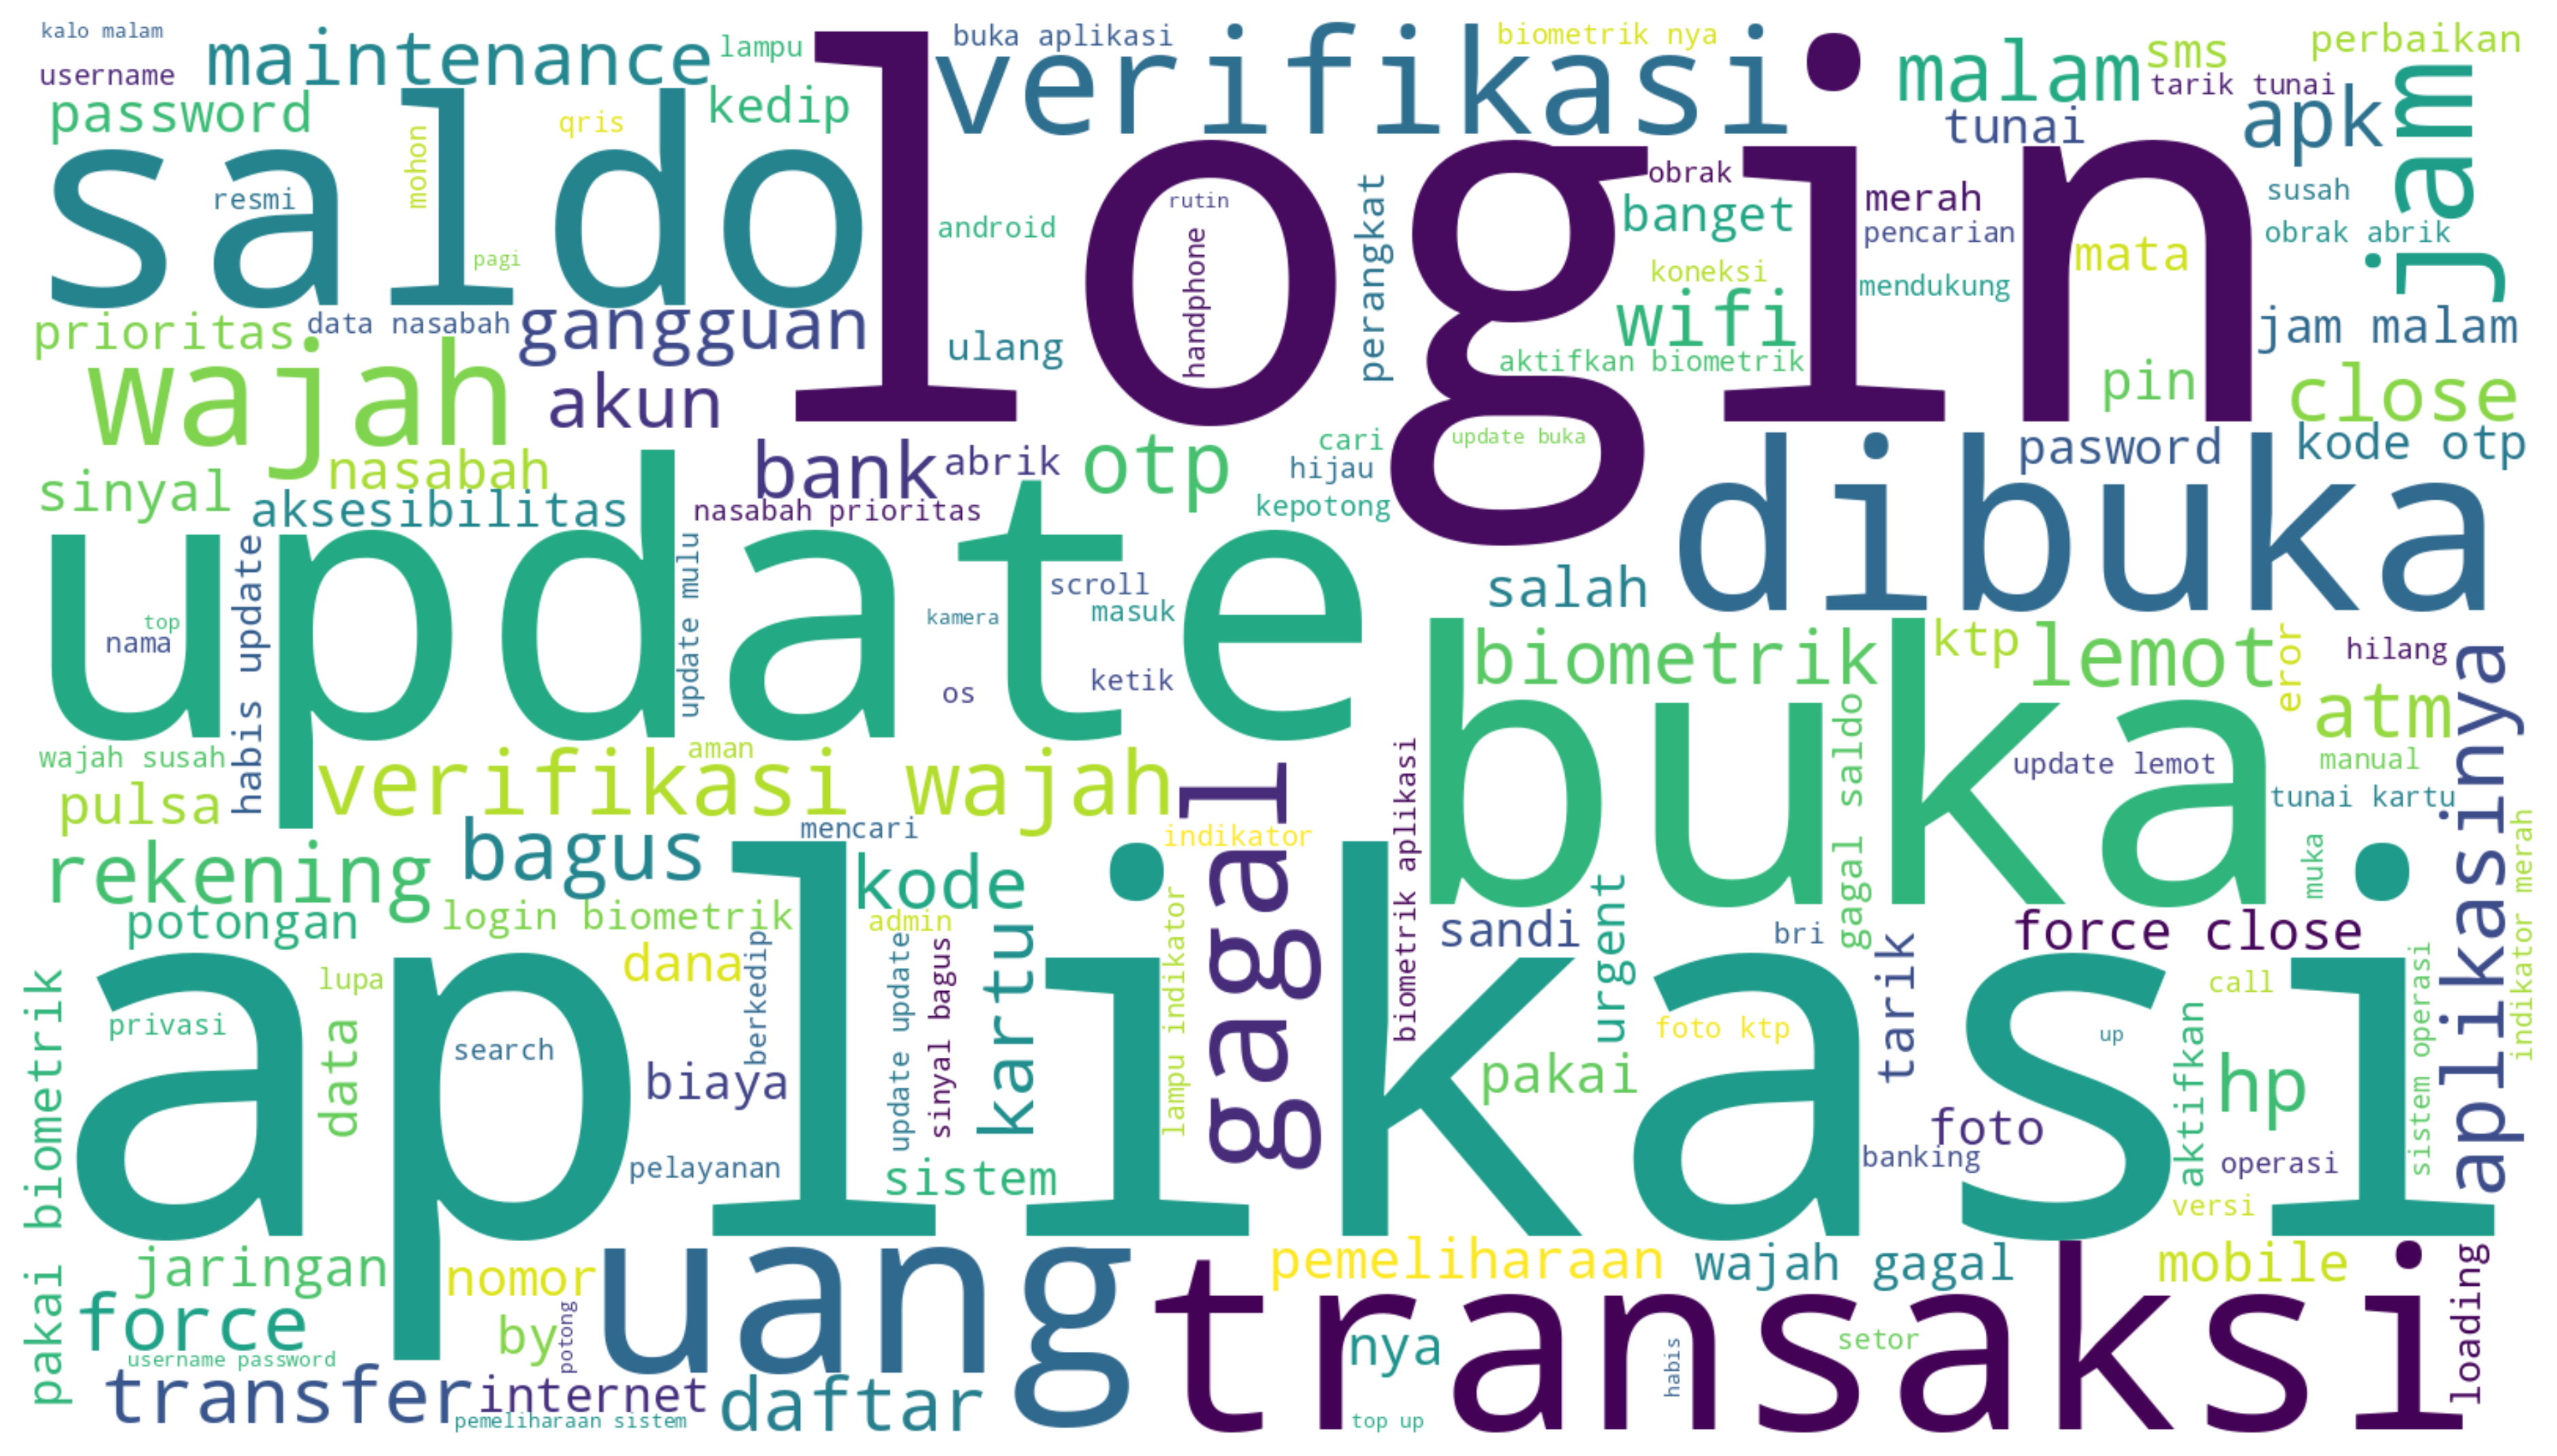

In [54]:
wc_k10 = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    max_words=150,
    colormap="viridis",
    random_state=42
).generate_from_frequencies(topic_word_weights)

# Render Gambar Matplotlib
plt.figure(figsize=(16, 9), dpi=300)
plt.imshow(wc_k10, interpolation="bilinear")
plt.axis("off")
plt.show()

# Single K Value Testing

In [33]:
k_test = 9

print(f" RUNNING EVALUATION FOR K = {k_test}")

k9_table_rows = []

for bank_info in bank_mapping:
    bank_name = bank_info["display"]
    docs = bank_data_store[bank_name]["docs"]
    embeddings = bank_data_store[bank_name]["embeddings"]
    total_data = bank_data_store[bank_name]["total_data"]
    
    # Fresh Vectorizer instance per bank
    bank_vectorizer = CountVectorizer(
        ngram_range=(1, 2),
        stop_words=topic_stopwords,
        token_pattern=r"(?u)\b[^\d\W]{2,}\b",
        min_df=0.01
    )
    
    # GPU UMAP Dimensionality Reduction
    umap_gpu = UMAP(
        n_neighbors=15,
        n_components=10,
        metric="cosine",
        min_dist=0.0,
        random_state=42
    )
    
    # GPU K-Means Clustering for K = 9
    kmeans_gpu = KMeans(
        n_clusters=k_test,
        init="k-means++",
        max_iter=300,
        random_state=42
    )
    
    # Construct BERTopic Pipeline
    topic_model = BERTopic(
        embedding_model=None,
        calculate_probabilities=False,
        vectorizer_model=bank_vectorizer,
        umap_model=umap_gpu,
        hdbscan_model=kmeans_gpu,
        ctfidf_model=ctfidf_model,
        verbose=False
    )
    
    # Fit topic model
    topics, _ = topic_model.fit_transform(docs, embeddings)
    
    # Calculate Evaluation Metrics
    sil_score = calculate_silhouette(topic_model.umap_model.embedding_, topics)
    npmi_score = calculate_npmi(topic_model, docs, top_n=10)
    td_score = calculate_topic_diversity(topic_model, top_n=10)
    
    k9_table_rows.append({
        "Bank": bank_name,
        "Silhouette": sil_score,
        "NPMI": npmi_score,
        "Topic Diversity": td_score,
        "Total Data": total_data
    })

 RUNNING EVALUATION FOR K = 9


In [34]:
k9_df = pd.DataFrame(k9_table_rows)
display(style_evaluation_table(k9_df, k_val=9))

Bank,Silhouette,NPMI,Topic Diversity,Total Data
Mandiri,"0,3811","0,1434","0,82",14.408
BRI,"0,3447","0,1514","0,79",18.412
BNI,"0,4176","0,1529","0,81",11.307
BCA,"0,5315","0,1807","0,89",7.687


In [35]:
all_results_k9 = {9: k9_df}

export_topics_to_docx_per_k_with_eval(
    bank_data_store, 
    bank_mapping, 
    topic_stopwords, 
    ctfidf_model, 
    all_results=all_results_k9, 
    k_values=[9]
)


 GENERATING DOCX FOR K = 9 -> Bank_Topic_Modeling_Evaluation_K9.docx
  Extracting topics for Mandiri...
  Extracting topics for BRI...
  Extracting topics for BNI...
  Extracting topics for BCA...
Saved: /root/VsCode Linux/topic_modeling_KBMI4/2025/Bank_Topic_Modeling_Evaluation_K9.docx
